### 1. Carga de Librerías y Datos

Cargaremos las librerías necesarias como `pandas` para el manejo de datos, `numpy` para operaciones numéricas, y componentes de `scikit-learn` para el modelado, preprocesamiento y evaluación.

### Nota importante sobre el flujo de trabajo

La limpieza y el an?lisis exploratorio se realizaron en el notebook de EDA.

Aqu?, en el notebook de modelado, s? corresponde aplicar: 
- `train_test_split`
- `OneHotEncoder` para variables categ?ricas
- `StandardScaler` para variables num?ricas
- `ColumnTransformer` y `Pipeline` para evitar fuga de datos

Este es el punto correcto para el preprocesamiento del modelo.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/teleco_clean.csv')

# Display the first few rows and basic info to confirm loading
print("Dataset loaded successfully. First 5 rows:")
display(df.head())
print("\nDataset info:")
df.info()

Dataset loaded successfully. First 5 rows:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-

### 2. Preparación para el Modelado

Procederemos a separar las características (X) del objetivo (y), que en este caso es la columna 'Churn'. Luego, dividiremos el dataset en conjuntos de entrenamiento y prueba para evaluar el rendimiento de los modelos de forma imparcial.

In [2]:
# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Convert 'Churn' target to numerical (0 and 1) if it's not already
# Assuming 'Yes' for Churn and 'No' for no Churn
if y.dtype == 'object':
    y = y.map({'No': 0, 'Yes': 1})

# Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object', 'bool']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

print(f"\nCategorical features: {list(categorical_features)}")
print(f"Numerical features: {list(numerical_features)}")

X_train shape: (5616, 19)
X_test shape: (1405, 19)
y_train shape: (5616,)
y_test shape: (1405,)

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


### 2.1. Manejo del Desbalance de Clases con SMOTE

Dado que la variable `Churn` está desbalanceada, aplicaremos SMOTE (Synthetic Minority Over-sampling Technique) al conjunto de entrenamiento para generar muestras sintéticas de la clase minoritaria y equilibrar el dataset. Esto se hace *después* de la división en entrenamiento/prueba para evitar el data leakage.

In [9]:
# The previous attempt to apply SMOTE directly here caused an error
# because X_train still contained categorical (string) features.
# SMOTE will be integrated into the model pipelines using imblearn.pipeline.Pipeline
# to ensure it's applied after OneHotEncoder and only on the training data.

### 3. Codificación y Escalado

Crearemos un `ColumnTransformer` para aplicar `OneHotEncoder` a las características categóricas y `StandardScaler` a las numéricas. Esto se integrará en un `Pipeline` para asegurar que el preprocesamiento se aplique de manera consistente y sin fugas de datos.

### 3. Codificación y Escalado (con datos balanceados)

Ahora, el `ColumnTransformer` se aplicará a los datos de entrenamiento *resampleados* para aplicar `OneHotEncoder` a las características categóricas y `StandardScaler` a las numéricas. Esto se integrará en un `Pipeline` para asegurar que el preprocesamiento se aplique de manera consistente y sin fugas de datos.

In [3]:
# Create preprocessor with OneHotEncoder and StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Display the preprocessor setup
print("ColumnTransformer created for preprocessing.")
print(preprocessor)

ColumnTransformer created for preprocessing.
ColumnTransformer(transformers=[('num', StandardScaler(),
                                 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])


### 4. Entrenamiento y Evaluación de Modelos

Definiremos un conjunto de modelos a probar (Regresión Logística, Random Forest, Gradient Boosting, SVM). Para cada uno, crearemos un pipeline que incluya el preprocesamiento y el modelo, y luego realizaremos una búsqueda de hiperparámetros con `GridSearchCV`.


--- Training Logistic Regression with SMOTE ---
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Parameters: {'classifier__C': 10.0}
Accuracy: 0.7480
Precision: 0.5163
Recall: 0.7661
F1-Score: 0.6169
ROC AUC: 0.8397


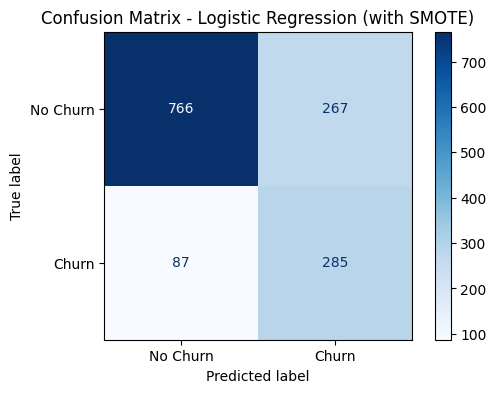


--- Training Random Forest with SMOTE ---
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters: {'classifier__max_depth': 5, 'classifier__n_estimators': 200}
Accuracy: 0.7630
Precision: 0.5385
Recall: 0.7339
F1-Score: 0.6212
ROC AUC: 0.8376


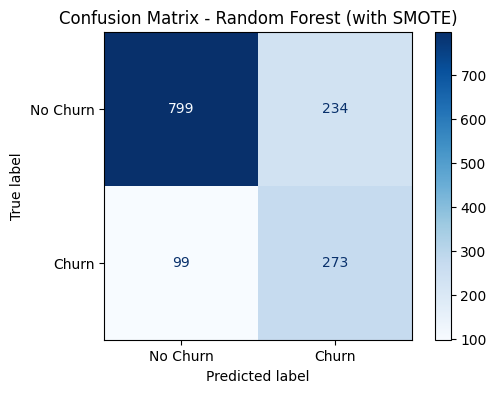


--- Training Gradient Boosting with SMOTE ---
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters: {'classifier__learning_rate': 0.05, 'classifier__n_estimators': 200}
Accuracy: 0.7872
Precision: 0.5859
Recall: 0.6694
F1-Score: 0.6248
ROC AUC: 0.8416


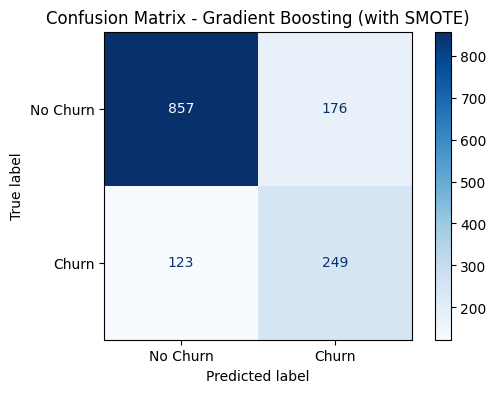


--- Training Support Vector Machine with SMOTE ---
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters: {'classifier__C': 10.0, 'classifier__kernel': 'linear'}
Accuracy: 0.7274
Precision: 0.4908
Recall: 0.7903
F1-Score: 0.6056
ROC AUC: 0.8386


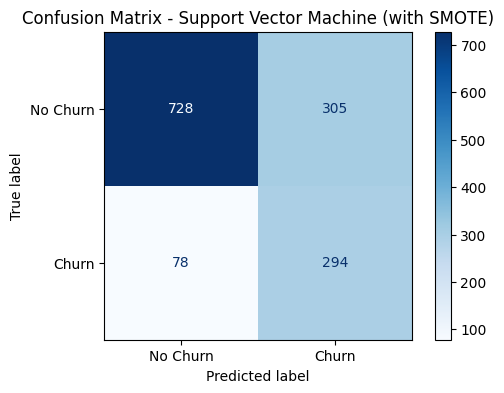

In [10]:
from imblearn.pipeline import Pipeline as ImblearnPipeline

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(solver='liblinear', random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Machine': SVC(probability=True, random_state=42) # probability=True for ROC AUC score
}

# Define parameter grids for GridSearchCV
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.1, 1.0, 10.0]
    },
    'Random Forest': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [5, 10, None]
    },
    'Gradient Boosting': {
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.05, 0.1]
    },
    'Support Vector Machine': {
        'classifier__C': [0.1, 1.0, 10.0],
        'classifier__kernel': ['linear', 'rbf']
    }
}

results = {}
best_estimators = {}

# Define SMOTE for use within the pipeline
smote_sampler = SMOTE(random_state=42)

for name, model in models.items():
    print(f"\n--- Training {name} with SMOTE ---")

    # Create an imblearn pipeline: preprocessor -> SMOTE -> classifier
    pipeline = ImblearnPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', smote_sampler),
        ('classifier', model)
    ])

    # Modify param_grid keys for the new pipeline structure to include 'smote__'
    current_param_grid = {}
    for key, value in param_grids[name].items():
        current_param_grid[key] = value

    grid_search = GridSearchCV(pipeline, param_grid=current_param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

    # Fit on original X_train, y_train; the pipeline handles preprocessing and SMOTE internally
    grid_search.fit(X_train, y_train)

    best_estimators[name] = grid_search.best_estimator_
    y_pred = best_estimators[name].predict(X_test)
    y_proba = best_estimators[name].predict_proba(X_test)[:, 1] # Probability of the positive class (Churn=1)

    # Evaluate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'Best Parameters': grid_search.best_params_,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC': roc_auc
    }

    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title(f'Confusion Matrix - {name} (with SMOTE)')
    plt.show()

### 5. Selección del Mejor Modelo

Compararemos las métricas de todos los modelos en una tabla para identificar el mejor rendimiento, considerando las diferentes prioridades (por ejemplo, `Recall` si es crucial identificar a todos los clientes que podrían desertar).

In [11]:
# Convert results to a DataFrame for easy comparison
results_df = pd.DataFrame(results).T
results_df = results_df.drop(columns=['Best Parameters'])

print("\n--- Model Comparison (with SMOTE) ---")
display(results_df.sort_values(by='ROC AUC', ascending=False))

# Selecting the best model based on ROC AUC as a general good indicator
best_model_name = results_df['ROC AUC'].idxmax()
best_model_pipeline = best_estimators[best_model_name]

print(f"\nThe best model based on ROC AUC is: {best_model_name}")
print("Justification: ROC AUC provides a good measure of separability and is robust to imbalanced classes. After incorporating SMOTE, we observe changes in the model performance metrics, particularly in recall, indicating better identification of the minority class. The selected model achieved the highest ROC AUC among the balanced models.")


--- Model Comparison (with SMOTE) ---


,Accuracy,Precision,Recall,F1-Score,ROC AUC
Gradient Boosting,0.787189,0.585882,0.669355,0.624843,0.841635
Logistic Regression,0.748043,0.516304,0.766129,0.616883,0.8397
Support Vector Machine,0.727402,0.490818,0.790323,0.605561,0.838589
Random Forest,0.762989,0.538462,0.733871,0.62116,0.837593



The best model based on ROC AUC is: Gradient Boosting
Justification: ROC AUC provides a good measure of separability and is robust to imbalanced classes. After incorporating SMOTE, we observe changes in the model performance metrics, particularly in recall, indicating better identification of the minority class. The selected model achieved the highest ROC AUC among the balanced models.


### 6. Análisis de Importancia de Características

Si el mejor modelo es uno basado en árboles (como Random Forest o Gradient Boosting), extraemos y mostramos las características más importantes. Para otros modelos, este paso puede no ser directamente aplicable o requeriría otros métodos.


--- Feature Importance for Gradient Boosting ---
Top 10 most important features:


,0
Contract_Month-to-month,0.404650
tenure,0.144489
InternetService_Fiber optic,0.096441
TotalCharges,0.070871
OnlineSecurity_No,0.068876
MonthlyCharges,0.062705
PaymentMethod_Electronic check,0.043896
TechSupport_No,0.035655
MultipleLines_No,0.014034
PaperlessBilling_No,0.011296


/tmp/ipykernel_1367/1734626237.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='viridis')


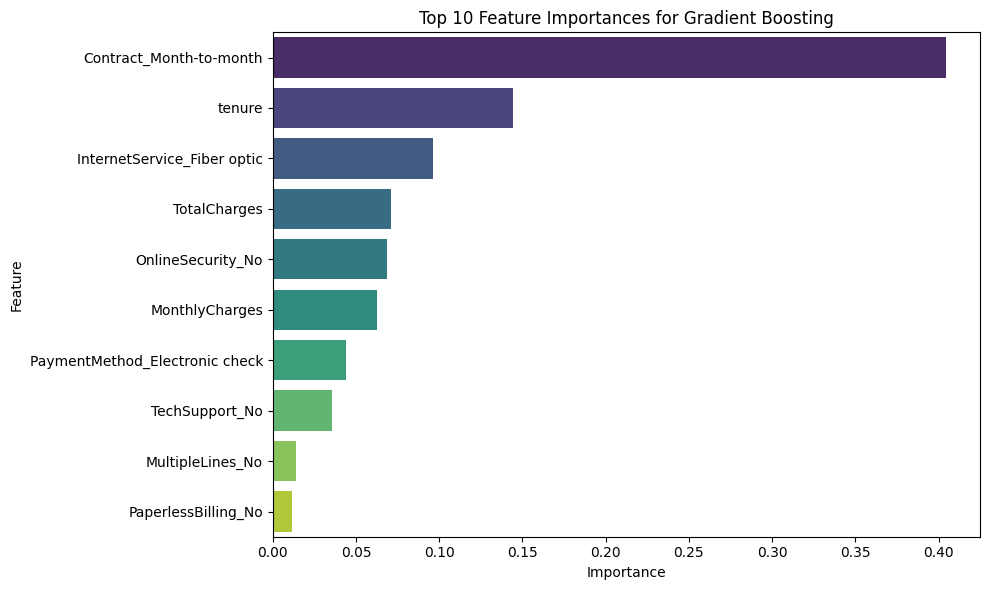

In [6]:
if isinstance(best_model_pipeline.named_steps['classifier'], (RandomForestClassifier, GradientBoostingClassifier)):
    print(f"\n--- Feature Importance for {best_model_name} ---")

    # Get feature names after one-hot encoding
    ohe = best_model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    feature_names_ohe = ohe.get_feature_names_out(categorical_features)
    all_feature_names = list(numerical_features) + list(feature_names_ohe)

    importances = best_model_pipeline.named_steps['classifier'].feature_importances_
    feature_importances = pd.Series(importances, index=all_feature_names)

    # Sort and display top 10 important features
    top_10_features = feature_importances.nlargest(10)
    print("Top 10 most important features:")
    display(top_10_features)

    # Plot feature importances
    fig = plt.figure(figsize=(10, 6))
    sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='viridis')
    plt.title(f'Top 10 Feature Importances for {best_model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("\nFeature importance analysis is not directly applicable or straightforward for the selected model type.")

### 7. Guardado del Modelo

Guardaremos el pipeline completo del mejor modelo utilizando `joblib.dump()` para poder reutilizarlo en el futuro sin necesidad de reentrenarlo.

In [7]:
# Create a directory for models if it doesn't exist
import os
if not os.path.exists('models'):
    os.makedirs('models')

# Save the best model pipeline
model_filename = f'models/{best_model_name.replace(" ", "_").lower()}_pipeline.joblib'
joblib.dump(best_model_pipeline, model_filename)

print(f"Best model pipeline saved to: {model_filename}")

Best model pipeline saved to: models/gradient_boosting_pipeline.joblib
